# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset : **Mental Health Indo Dataset**

Link    : https://www.kaggle.com/datasets/arkaradithya/multimodal-mental-health-indo-dataset


# **INFORMASI DATASET**

This dataset is a specialized textual corpus designed for detecting depressive symptoms and suicidal ideation within the Indonesian Twitter (X) landscape. The dataset is curated specifically for training NLP and Large Language Models.

The dataset contains 7,991 rows of labeled tweets, compiled using a hybrid approach:

Base Data: Sourced from an established Kaggle dataset by Steven Hans.
Data Augmentation: The data was augmented using the LLaMA-3.3-70B-Versatile LLM to introduce Gen-Z slang, implicit hopelessness contexts, and suicidal ideation metaphors, strictly without altering the original class labels.
Clinical Validation: To ensure diagnostic accuracy and clinical reliability, a representative sample of the dataset—specifically the highly ambiguous tweets—has been rigorously reviewed and validated by a professional clinical psychologist acting as the gold standard.
# Data Structure

text: The raw textual content of the tweet.
label: The classification target (1 / Depresi = Indicates depressive symptoms or suicidal ideation, 0 / Normal = Indicates normal daily activities or non-depressive vents).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [21]:
'''
#DOWNGRADE to PYTHON 3.12.7
# 1. Install alat dan library yang dibutuhkan untuk kompilasi Python
!sudo apt-get update
!sudo apt-get install build-essential zlib1g-dev libncurses5-dev libgdbm-dev libnss3-dev libssl-dev libreadline-dev libffi-dev libsqlite3-dev wget libbz2-dev -y

# 2. Unduh source code resmi Python 3.12.7
!wget https://www.python.org/ftp/python/3.12.7/Python-3.12.7.tgz

# 3. Ekstrak file yang diunduh
!tar -xf Python-3.12.7.tgz

# 4. Masuk ke folder, konfigurasi sistem, dan kompilasi (Gunakan semua core CPU agar cepat)
%cd Python-3.12.7
!./configure --enable-optimizations
!make -j$(nproc)
!sudo make altinstall
%cd ..

# 5. Arahkan perintah 'python3' di sistem Colab ke Python 3.12.7 yang baru di-install
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/local/bin/python3.12 1
!sudo update-alternatives --set python3 /usr/local/bin/python3.12

# 6. Install ulang PIP agar terhubung ke Python 3.12.7
!curl https://bootstrap.pypa.io/get-pip.py -o get-pip.py
!python3 get-pip.py --force-reinstall

# 7. Pasang kernel interaktif agar sistem Colab tidak crash saat runtime di-restart
#!pip install ipykernel
'''

"\n#DOWNGRADE to PYTHON 3.12.7\n# 1. Install alat dan library yang dibutuhkan untuk kompilasi Python\n!sudo apt-get update\n!sudo apt-get install build-essential zlib1g-dev libncurses5-dev libgdbm-dev libnss3-dev libssl-dev libreadline-dev libffi-dev libsqlite3-dev wget libbz2-dev -y\n\n# 2. Unduh source code resmi Python 3.12.7\n!wget https://www.python.org/ftp/python/3.12.7/Python-3.12.7.tgz\n\n# 3. Ekstrak file yang diunduh\n!tar -xf Python-3.12.7.tgz\n\n# 4. Masuk ke folder, konfigurasi sistem, dan kompilasi (Gunakan semua core CPU agar cepat)\n%cd Python-3.12.7\n!./configure --enable-optimizations\n!make -j$(nproc)\n!sudo make altinstall\n%cd ..\n\n# 5. Arahkan perintah 'python3' di sistem Colab ke Python 3.12.7 yang baru di-install\n!sudo update-alternatives --install /usr/bin/python3 python3 /usr/local/bin/python3.12 1\n!sudo update-alternatives --set python3 /usr/local/bin/python3.12\n\n# 6. Install ulang PIP agar terhubung ke Python 3.12.7\n!curl https://bootstrap.pypa.io/get-

In [ ]:
#!pip install gensim sastrawi python-Levenshtein saka-nlp wordcloud mpstemmer 

  Using cached gensim-4.4.0-cp312-cp312-win_amd64.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.4 MB 6.3 MB/s eta 0:00:04
   --- ------------------------------------ 2.1/24.4 MB 5.3 MB/s eta 0:00:05
   ---- ----------------------------------- 2.9/24.4 MB 4.8 MB/s eta 0:00:05
   ------ --------------------------------- 3.9/24.4 MB 4.9 MB/s eta 0:00:05
   --------- ------------------------------ 5.5/24.4 MB 5.3 MB/s eta 0:00:04
   ----------- ---------------------------- 6.8/24.4 MB 5.7 MB/s eta 0:00:04
   ------------- -------------------------- 8.4/24.4 MB 5.8 MB/s eta 0:00:03
   ---------------- ----------------------- 10.0/24.4 MB 6.0 MB/s eta 0:00:03
   ------------------ --------------------- 11.3/24.4 MB 6.2 MB/s eta 0:00:03
   --------------------- ------------------ 12.8/24.4 MB 6.2 MB/s eta 0:00:02
   ----------------------- ---------------- 14.2/24.4 MB 6.3 MB/s eta 0:00:02
   ----


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#%pip install --upgrade git+https://github.com/ariaghora/mpstemmer.git

  Cloning https://github.com/ariaghora/mpstemmer.git to c:\users\asus\appdata\local\temp\pip-req-build-6j__rluk
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git 'C:\Users\Asus\AppData\Local\Temp\pip-req-build-6j__rluk'

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#!python --version

Python 3.12.7


In [ ]:
#!pip install python-Levenshtein


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import csv
import datetime as dt
from io import StringIO
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns  # PERBAIKAN: Menambahkan import seaborn yang terlewat
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import numpy as np
import pandas as pd
import requests
#from google.colab import drive
from mpstemmer import MPStemmer
from wordcloud import WordCloud
from collections import Counter


# UNDUH RESOURCE NLTK YANG DIBUTUHKAN (Wajib dijalankan kembali setelah ganti versi Python)
nltk.download('punkt')
nltk.download('punkt_tab')  # Ini data yang memicu error sebelumnya
nltk.download('stopwords')

# Mengimpor Sastrawi & Saka
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import saka

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [27]:
'''
drive.mount('/content/drive')
path_file='/content/drive/MyDrive/SMSML_Mujtahidul_Haq_Mahyunda/mental-health-indo-dataset-text.csv'
df = pd.read_csv(path_file)
'''

"\ndrive.mount('/content/drive')\npath_file='/content/drive/MyDrive/SMSML_Mujtahidul_Haq_Mahyunda/mental-health-indo-dataset-text.csv'\ndf = pd.read_csv(path_file)\n"

In [28]:
import os
print("Lokasi saat ini:", os.getcwd())
print("Isi folder saat ini:", os.listdir('.'))

Lokasi saat ini: c:\Users\Asus\OneDrive\Documents\SMSML_Mujtahidul_Haq_Mahyunda\preprocessing
Isi folder saat ini: ['automate_Mujtahidul_Haq_Mahyunda.ipynb', 'automate_Mujtahidul_Haq_Mahyunda.py', 'data_clean_mental_health_indo.csv', 'Eksperimen_MSML_Mujtahidul_Haq_Mahyunda.ipynb', 'Eksperimen_MSML_Mujtahidul_Haq_Mahyunda1.ipynb']


In [29]:
%pwd && ls -R

'c:\\Users\\Asus\\OneDrive\\Documents\\SMSML_Mujtahidul_Haq_Mahyunda\\preprocessing'

In [30]:
import pandas as pd

# Ganti '/content/nama_folder_proyek_anda/' sesuai dengan hasil print os.getcwd() atau pwd di atas
path_file = '../mental-health-indo-dataset-text.csv'

df = pd.read_csv(path_file)
df.head()

,text,label
0,gelisah bgt astaga,1.0
1,"tidur susah, pikiran kacau, hati gelisah. Semu...",1.0
2,"Serba salah, mundur sayang, maju ragu. Diem di...",1.0
3,Udah ngalihin fokus ke yang lain tapi tetep cemas,1.0
4,"Resah dan gelisah deh mimin, dah sebulan lewat...",1.0


In [31]:
#path_file = '../mental-health-indo-dataset-text.csv'

# Membaca file CSV ke DataFrame
#df = pd.read_csv(path_file)

# Menampilkan data
#df.head()

In [32]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7991 entries, 0 to 7990
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    7991 non-null   object 
 1   label   7989 non-null   float64
dtypes: float64(1), object(1)
memory usage: 125.0+ KB


In [33]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,label
count,7989.000000
mean,0.218050
std,0.412947
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14852\4100481900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


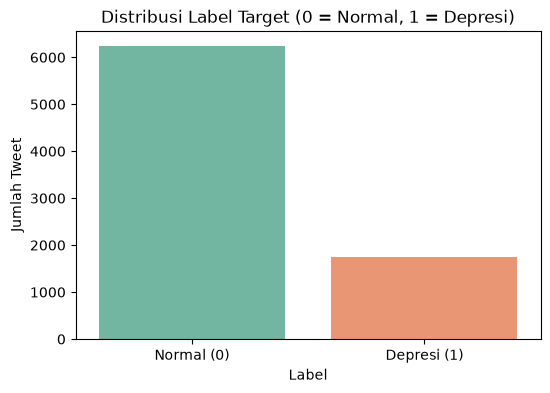

label
0.0    78.195018
1.0    21.804982
Name: proportion, dtype: float64


In [34]:
plt.figure(figsize=(6, 4))
# Menghitung jumlah per label
sns.countplot(x='label', data=df, palette='Set2')

plt.title('Distribusi Label Target (0 = Normal, 1 = Depresi)')
plt.xlabel('Label')
plt.ylabel('Jumlah Tweet')
plt.xticks([0, 1], ['Normal (0)', 'Depresi (1)'])
plt.show()

# Menampilkan persentase secara teks
print(df['label'].value_counts(normalize=True) * 100)

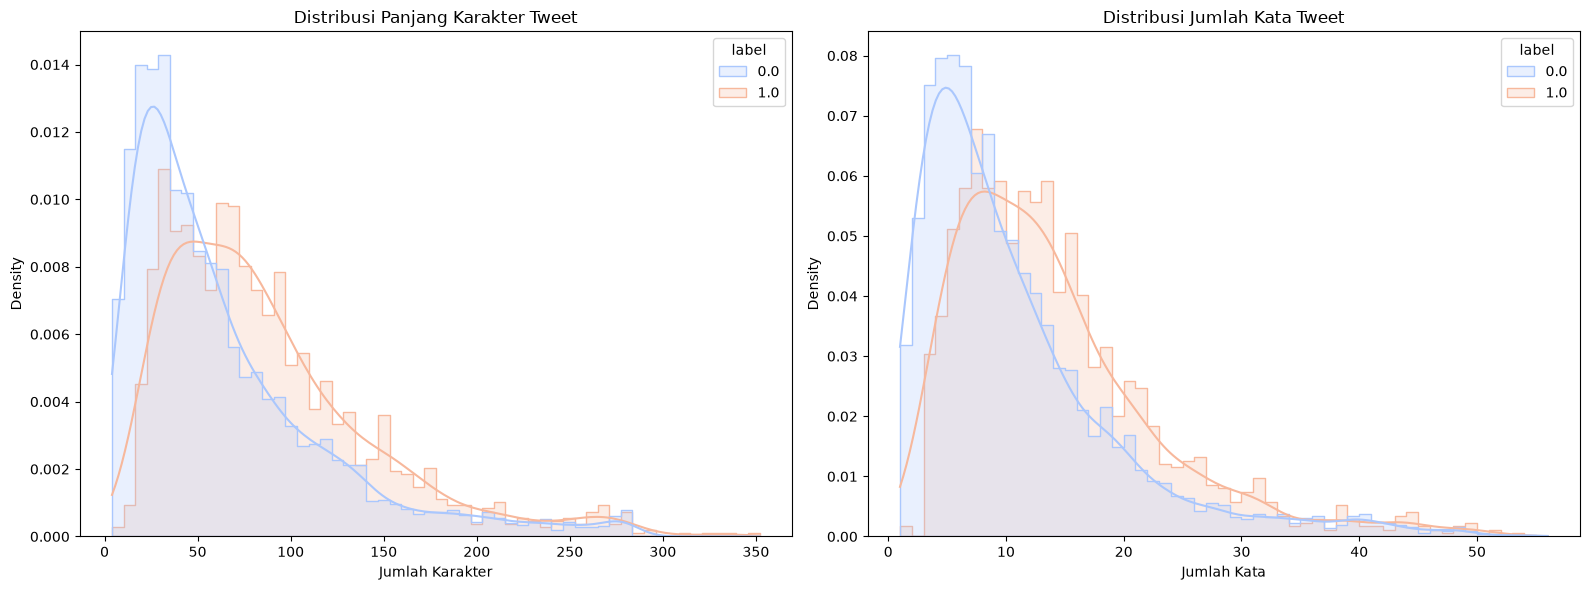

In [35]:
# Membuat fitur baru berupa panjang karakter dan jumlah kata
df['char_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

# Visualisasi perbandingan panjang karakter berdasarkan label
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram Panjang Karakter
sns.histplot(data=df, x='char_length', hue='label', kde=True, element='step', stat='density', common_norm=False, ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribusi Panjang Karakter Tweet')
axes[0].set_xlabel('Jumlah Karakter')

# Histogram Jumlah Kata
sns.histplot(data=df, x='word_count', hue='label', kde=True, element='step', stat='density', common_norm=False, ax=axes[1], palette='coolwarm')
axes[1].set_title('Distribusi Jumlah Kata Tweet')
axes[1].set_xlabel('Jumlah Kata')

plt.tight_layout()
plt.show()

In [36]:
'''
# Menampilkan korelasi antar fitur (Opsional Skilled 1)

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns

# Hitung matriks korelasi
correlation = df[numerical_cols].corr()

# Buat visualisasi heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()
'''

'\n# Menampilkan korelasi antar fitur (Opsional Skilled 1)\n\n# Memilih kolom numerik\nnumerical_cols = df.select_dtypes(include=[\'number\']).columns\n\n# Hitung matriks korelasi\ncorrelation = df[numerical_cols].corr()\n\n# Buat visualisasi heatmap\n\nplt.figure(figsize=(10, 6))\nsns.heatmap(correlation,\n               annot=True,\n               cmap=\'coolwarm\',\n               fmt=".2f",\n               vmin=-1,\n               vmax=1)\nplt.title(\'Correlation Matrix\')\nplt.show()\n'

In [37]:
'''
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    # Tampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar
    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()
'''

'\n# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)\n\nfig, axes = plt.subplots(2, 3, figsize=(18, 8))\naxes = axes.flatten()\n\nfor i, column in enumerate(numerical_cols):\n\n    # Tampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar\n    sns.histplot(df[column], bins=20, kde=True, color=\'skyblue\', ax=axes[i])\n\n    # Atur judul dan label\n    axes[i].set_title(column)\n    axes[i].set_xlabel("Nilai")\n    axes[i].set_ylabel("Frekuensi")\n\nplt.tight_layout()\nplt.show()\n'

In [38]:
'''
# Visualisasi yang lebih informatif (Opsional Advanced 1)

plt.figure(figsize=(12, 6))

# Buat visualisasi boxplot untuk melihat sebaran 'TransactionAmount' (y) berdasarkan 'CustomerOccupation' (x)
sns.boxplot(x='CustomerOccupation', y='TransactionAmount', data=df)

plt.title("Nilai Transaksi per Pekerjaan Nasabah (Boxplot)")

# Putar label sumbu-x agar tidak tumpang tindih
plt.xticks(rotation=45)

plt.show()

# -----------------------------------------------------------------
# (TANTANGAN OPSIONAL)
# -----------------------------------------------------------------
# Sekarang, bagaimana jika kita juga ingin melihat kepadatan distribusi data di setiap kategori?
# Coba buat visualisasi lain di bawah ini, misalnya 'violinplot' (sns.violinplot) dengan parameter yang sama.
plt.figure(figsize=(12, 6))
sns.violinplot(x='CustomerOccupation', y='TransactionAmount', data=df)
plt.title("Kepadatan Distribusi Nilai Transaksi per Pekerjaan Nasabah (Violinplot)")
plt.xticks(rotation=45)
plt.show()
'''

'\n# Visualisasi yang lebih informatif (Opsional Advanced 1)\n\nplt.figure(figsize=(12, 6))\n\n# Buat visualisasi boxplot untuk melihat sebaran \'TransactionAmount\' (y) berdasarkan \'CustomerOccupation\' (x)\nsns.boxplot(x=\'CustomerOccupation\', y=\'TransactionAmount\', data=df)\n\nplt.title("Nilai Transaksi per Pekerjaan Nasabah (Boxplot)")\n\n# Putar label sumbu-x agar tidak tumpang tindih\nplt.xticks(rotation=45)\n\nplt.show()\n\n# -----------------------------------------------------------------\n# (TANTANGAN OPSIONAL)\n# -----------------------------------------------------------------\n# Sekarang, bagaimana jika kita juga ingin melihat kepadatan distribusi data di setiap kategori?\n# Coba buat visualisasi lain di bawah ini, misalnya \'violinplot\' (sns.violinplot) dengan parameter yang sama.\nplt.figure(figsize=(12, 6))\nsns.violinplot(x=\'CustomerOccupation\', y=\'TransactionAmount\', data=df)\nplt.title("Kepadatan Distribusi Nilai Transaksi per Pekerjaan Nasabah (Violinplot)"

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [39]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

text           0
label          2
char_length    0
word_count     0
dtype: int64

In [40]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(78)

In [41]:
app_reviews_df = pd.read_csv(path_file)
app_reviews_df.info()
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna()
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
clean_df.info()
clean_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7991 entries, 0 to 7990
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    7991 non-null   object 
 1   label   7989 non-null   float64
dtypes: float64(1), object(1)
memory usage: 125.0+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 7911 entries, 0 to 7990
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    7911 non-null   object 
 1   label   7911 non-null   float64
dtypes: float64(1), object(1)
memory usage: 185.4+ KB


,label
count,7911.000000
mean,0.216660
std,0.411995
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [42]:

def cleaningText(text):
    # Ganti tanda baca dengan spasi terlebih dahulu agar kata tidak menempel
    text = re.sub(r'[\(\)\-\,\.\?\!\\\/]', ' ', text)
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['tiktok','tik','tok', 'aplikasi', 'aplikasinya', 'apk',
    'gitu', 'udh', 'deh', 'iya', 'yaa', 'gak', 'nya', 'na',
    'sih', 'ku', "di", "ga", "ya", "gaa", "loh", "kah",
    'banget', 'biar', 'doang', 'mohon', 'plis', 'si', 'kan', 'kok'])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

# 1. Inisialisasi objek MPStemmer di LUAR fungsi (cukup 1 kali saja)
mp_stemmer = MPStemmer()

# 2. Fungsi baru menggunakan mpstemmer
def stemmingText(text):
    # Karena mpstemmer punya fungsi .stem_kalimat(), kita tidak perlu lagi
    # melakukan .split() manual per kata. Langsung masukkan satu string kalimat.
    if isinstance(text, str) and text.strip():
        return mp_stemmer.stem_kalimat(text)
    return text

'''
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemmingText(text):
    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming menggunakan objek 'stemmer' yang ada di luar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text
'''

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [43]:
def fix_slangwords(text):
    if isinstance(text, str) and text.strip():
        return saka.normalize(text)
    return text

In [44]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['text'].apply(cleaningText)

In [45]:
# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

In [46]:
# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

In [47]:
# Mengganti kata-kata berimbuhan dengan kata-kata bentuk dasar dan menyimpannya di 'text_stemmed'
clean_df['text_stemmed'] = clean_df['text_slangwords'].apply(stemmingText)

In [48]:
clean_df.head()


,text,label,text_clean,text_casefoldingText,text_slangwords,text_stemmed
0,gelisah bgt astaga,1.0,gelisah bgt astaga,gelisah bgt astaga,gelisah banget astaga,gelisah banget astaga
1,"tidur susah, pikiran kacau, hati gelisah. Semu...",1.0,tidur susah pikiran kacau hati gelisah Semu...,tidur susah pikiran kacau hati gelisah semu...,tidur susah pikiran kacau hati gelisah semua t...,tidur susah pikir kacau hati gelisah semua tid...
2,"Serba salah, mundur sayang, maju ragu. Diem di...",1.0,Serba salah mundur sayang maju ragu Diem di...,serba salah mundur sayang maju ragu diem di...,serba salah mundur sayang maju ragu diem di te...,serba salah mundur sayang maju ragu diam di te...
3,Udah ngalihin fokus ke yang lain tapi tetep cemas,1.0,Udah ngalihin fokus ke yang lain tapi tetep cemas,udah ngalihin fokus ke yang lain tapi tetep cemas,sudah ngalihin fokus ke yang lain tapi tetep c...,sudah alih fokus ke yang lain tapi tetap cemas
4,"Resah dan gelisah deh mimin, dah sebulan lewat...",1.0,Resah dan gelisah deh mimin dah sebulan lewat...,resah dan gelisah deh mimin dah sebulan lewat...,resah dan gelisah deh mimin deh sebulan lewat ...,resah dan gelisah deh mim deh sebulan lewat co...


In [49]:
# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_stemmed'].apply(tokenizingText)

In [50]:
# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

In [51]:
# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [56]:
clean_df.head()
path_clean_file='data_clean_mental_health_indo.csv'
clean_df.to_csv(path_clean_file, index=False)

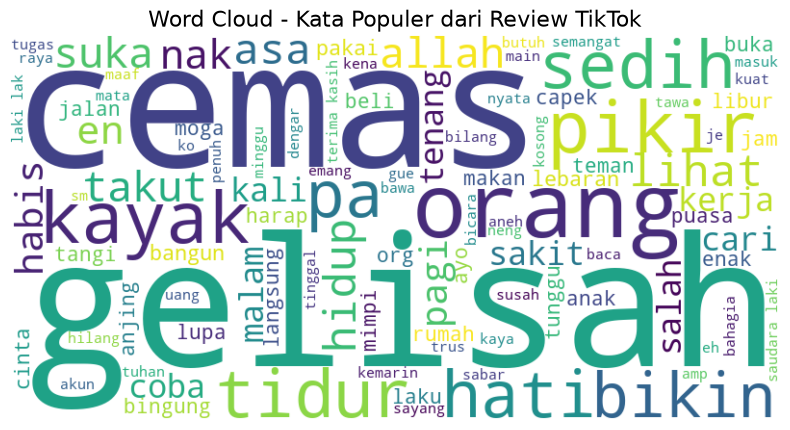

In [57]:
# VISUALISASI WORDCLOUD
# Menggabungkan semua teks akhir menjadi satu string panjang
all_words = ' '.join([text for text in clean_df['text_akhir']])

# Membuat dan menampilkan objek WordCloud
wordcloud = WordCloud(
    width=800, height=400, background_color='white', max_words=100
).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Kata Populer dari Review TikTok', fontsize=16)
#plt.savefig('grafik_saya1.png')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_14852\3283627107.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=top_words, palette='viridis')


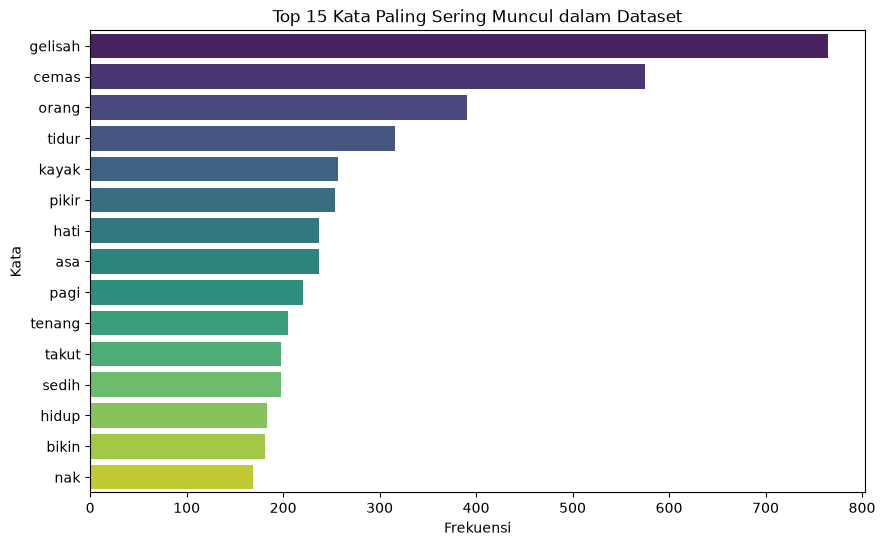

In [58]:
# Gabungkan semua kata dari tweet yang sudah bersih
all_words = ' '.join(clean_df['text_akhir'].astype(str)).split()

# Hitung frekuensi kemunculan setiap kata
word_freq = Counter(all_words)
top_words = pd.DataFrame(word_freq.most_common(15), columns=['Kata', 'Frekuensi'])

# Plot Barplot kata terpopuler
plt.figure(figsize=(10, 6))
sns.barplot(x='Frekuensi', y='Kata', data=top_words, palette='viridis')
plt.title('Top 15 Kata Paling Sering Muncul dalam Dataset')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.show()